# Interaction with Json Cache

https://github.com/Owen-Liuyuxuan/autoware_tf_data_engine?tab=readme-ov-file#output-format

```python
"""
Json file structure:
  str(frame_id) {
    frame: frame,
    objects: [
        {
            "id": object_id,
            "type": object_type as long,
            "transform": T [4, 4], - transform of the object in the world frame.
            "velocity": v [3], - velocity of the object in the world frame.
            "global_footprint": [4, 3] or [N, 3] - footprint of the object in the world frame. for rectangle and polygon
        },
        {},
    ],
    history_trajectories_transform_list: [N_h, 4, 4], past trajectory of the vehicle in the world frame. N=10,
    future_trajectories_transform_list: [N_f, 4, 4], future trajectory of the vehicle in the world frame. N=30,
    history_trajectories_speed_list: [N_h, 1], past speed of the vehicle in the world frame. N=10,
    future_trajectories_speed_list: [N_f, 1], future speed of the vehicle in the world frame. N=30,
    routes: [], list of lanelet2 id that is route of the vehicle in the neighborhood.
    nearby_lanelets_ids: [], list of lanelet2 id that is nearby the vehicle in the neighborhood.
    current_traffic_light_status:{  # latest perception traffic_light
      group_id:[  # the id is the same stuffs with the above
        {   ## https://docs.ros.org/en/humble/p/autoware_perception_msgs/msg/TrafficLightElement.html
          "color": int,
          "shape": int,
          "status": int,
          "confidence": float,
        },
        {}
      ]
    }
  }
  lanelet2_map # string of full path towards the map being used.
  vehicle_params: {  # all parameters are same with the vehicle_info definitions
    wheel_base 
    max_steer_angle
    wheel_base
    front_overhang
    rear_overhang
    left_overhang
    right_overhang
  }
"""
```

## Library and path settings

In [1]:
# Import lanelet2 relataed library
import lanelet2
## map projector info API only available in new version of the the extended APIs, otherwise please implement yourself
from autoware_lanelet2_extension_python.utility import load_info_from_yaml, MapProjectorInfo
from autoware_lanelet2_extension_python.projection import MGRSProjector
import autoware_lanelet2_extension_python.utility.utilities as utilities

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstLineString3d, std::allocator<lanelet::ConstLineString3d> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstPolygon3d, std::allocator<lanelet::ConstPolygon3d> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstLanelet, std::allocator<lanelet::ConstLanelet> > already registered; second conversion method ignored.


In [2]:
# Import preprocessing related libraries
import os
import json
import numpy as np

In [3]:
cache_path = "tutorial_docs/example_cache.json"

cache_data = {}
with open(cache_path, "r") as f:
    cache_data = json.load(f)

original_map_file = cache_data["lanelet2_map"]
original_map_file

'/home/ukenryu/autoware_map/shinagawa_odaiba_beta/lanelet2_map.osm'

> [!NOTE]  
> Generally, when we extract the ROSBag, we place the map in a correct path like `/home/autoware/autoware_map/{environment}/lanelet2_map.osm`. In the learning server, we are able to directly load the map if the path is configured the same.
> In this jupyter notebook, I will let this variable to be configured by the user.

In [4]:
map_file = "/home/ukenryu/autoware_map/shinagawa_odaiba_beta/lanelet2_map.osm"
map_projector_file = "/home/ukenryu/autoware_map/shinagawa_odaiba_beta/map_projector_info.yaml"

## Loading Map

### Helper functions  (can be folded)

In [5]:
## Helper functions
def get_lanelet2_projector(projector_info: MapProjectorInfo):
    """
    プロジェクタ情報に基づいて、適切なlanelet2のプロジェクタを返します。
    
    引数:
      projector_info: プロジェクタ情報を保持するオブジェクト
      
    戻り値:
      lanelet2のプロジェクタオブジェクト
      
    例外:
      ValueError: サポートされていないプロジェクタタイプが指定された場合
    """
    # LOCAL_CARTESIAN_UTM の場合
    if projector_info.projector_type == "LOCAL_CARTESIAN_UTM":
        position = lanelet2.GPSPoint(
            projector_info.map_origin.latitude,
            projector_info.map_origin.longitude,
            projector_info.map_origin.altitude
        )
        origin = lanelet2.io.Origin(position)
        return lanelet2.projection.UtmProjector(origin)
    
    # MGRS の場合
    elif projector_info.projector_type == "MGRS":
        projector = MGRSProjector(lanelet2.io.Origin(0, 0))
        projector.setMGRSCode(projector_info.mgrs_grid)
        return projector
    
    # TRANSVERSE_MERCATOR の場合
    elif projector_info.projector_type == "TRANSVERSE_MERCATOR":
        position = lanelet2.core.GPSPoint(
            projector_info.map_origin.latitude,
            projector_info.map_origin.longitude,
            projector_info.map_origin.altitude
        )
        origin = lanelet2.Origin(position)
        return TransverseMercatorProjector(origin)
    
    # LOCAL_CARTESIAN の場合
    elif projector_info.projector_type == "LOCAL_CARTESIAN":
        position = lanelet2.core.GPSPoint(
            projector_info.map_origin.latitude,
            projector_info.map_origin.longitude,
            projector_info.map_origin.altitude
        )
        origin = lanelet2.ioOrigin(position)
        return lanelet2.projection.LocalCartesianProjector(origin)

LANELET_TYPE_MAPPING = {
    "road": 0,
    "private": 1,
    "highway": 2,
    "play_street": 3,
    "emergency_lane": 4,
    "bus_lane": 5,
    "bicycle_lane": 6,
    "exit": 7,
    "walkway": 8,
    "shared_walkway": 9,
    "crosswalk": 10,
    "stairs": 11,
    "road_shoulder": 12,
    "pedestrian_lane": 13,
    "bicycle_lane": 14,
    "none": 15,
}

LANELET_LOCATION_MAPPING = {
    "urban": 0,
    "nonurban": 1,
    "private": 2,
    "none": 3
}

LANELET_TURN_DIRECTION_MAPPING =  {
    "straight": 0,
    "left": 1,
    "right": 2
}
    
def attribute_or(lanelet, key, default):
    if key in lanelet.attributes:
        return lanelet.attributes[key]
    return default

### Loading maps

In [6]:
projector = get_lanelet2_projector(load_info_from_yaml(map_projector_file))
map_object = lanelet2.io.load(map_file, projector)

## Indexing in the Keyframes

In [7]:
key_frame_ids = list(cache_data.keys())
key_frame_ids = [key for key in key_frame_ids if key not in ["lanelet2_map", "vehicle_params"]]
key_frame_ids.sort(key=lambda x:int(x))
print(key_frame_ids[:10], len(key_frame_ids))

['15', '20', '25', '30', '35', '40', '45', '50', '55', '60'] 1849


In [8]:
## Test the index
index = 80

In [9]:
frame_id = key_frame_ids[index]
frame = cache_data[str(frame_id)]
print(frame.keys()) # This will be the same in the JSON Scheme

dict_keys(['frame', 'objects', 'history_trajectories_transform_list', 'future_trajectories_transform_list', 'history_trajectories_speed_list', 'future_trajectories_speed_list', 'routes', 'nearby_lanelets_ids', 'associated_traffic_light_ids', 'current_traffic_light_status'])


In [10]:
objects = frame['objects']  # list of dictionary
# we can also use torch.tensor to formulate them into tensor; but in the notebook we focus on the visualization, so we use numpy
history_trajectory_transform = np.array(frame["history_trajectories_transform_list"], dtype=np.float64)  # [N_h, 4, 4] map frame
future_trajectory_transform = np.array(frame["future_trajectories_transform_list"], dtype=np.float64)    # [N_f, 4, 4] 
history_trajectory_speed = np.array(frame["history_trajectories_speed_list"], dtype=np.float64)          # [N_h, 1]
future_trajectory_speed = np.array(frame["future_trajectories_speed_list"], dtype=np.float64)            # [N_f, 1]
nearby_lanelets_ids = frame["nearby_lanelets_ids"] # list of ids
routes = frame["routes"] # list of ids
current_traffic_light_status = frame["current_traffic_light_status"]  # dictionary of list of group id
nearby_lanelets = [map_object.laneletLayer.get(idx) for idx in nearby_lanelets_ids]

In [11]:
# Demo code to print shape and type information

# Print information about objects
print("=== Objects ===")
print(f"Type: {type(objects)}")
print(f"Length: {len(objects)}")
if len(objects) > 0:
    print(f"First object type: {type(objects[0])}")
    print(f"First object keys: {objects[0].keys()}")
    
# Print information about trajectories
print("\n=== Trajectories ===")
print(f"History trajectory transform shape: {history_trajectory_transform.shape}")
print(f"Future trajectory transform shape: {future_trajectory_transform.shape}")
print(f"History trajectory speed shape: {history_trajectory_speed.shape}")
print(f"Future trajectory speed shape: {future_trajectory_speed.shape}")

# Print information about nearby lanelets
print("\n=== Nearby Lanelets ===")
print(f"Type: {type(nearby_lanelets_ids)}")
print(f"Length: {len(nearby_lanelets_ids)}")
if len(nearby_lanelets_ids) > 0:
    print(f"First lanelet type: {type(nearby_lanelets_ids[0])}")

print("\n=== Routes ===")
print(f"Type: {type(routes)}")
print(f"Length: {len(routes)}")
if len(routes) > 0:
    print(f"First lanelet type: {type(routes[0])}")
    
# Print information about traffic light status
print("\n=== Traffic Light Status ===")
print(f"Type: {type(current_traffic_light_status)}")
print(f"Keys: {current_traffic_light_status.keys() if isinstance(current_traffic_light_status, dict) else 'Not a dictionary'}")

# Print a sample of the first object if available
if len(objects) > 0:
    print("\n=== Sample Object Data ===")
    obj = objects[0]
    for key, value in obj.items():
        print(f"{key}: {type(value)}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"  Length: {len(value)}")


=== Objects ===
Type: <class 'list'>
Length: 8
First object type: <class 'dict'>
First object keys: dict_keys(['id', 'type', 'transform', 'velocity', 'footprint', 'global_footprint'])

=== Trajectories ===
History trajectory transform shape: (10, 4, 4)
Future trajectory transform shape: (30, 4, 4)
History trajectory speed shape: (10,)
Future trajectory speed shape: (30,)

=== Nearby Lanelets ===
Type: <class 'list'>
Length: 82
First lanelet type: <class 'int'>

=== Routes ===
Type: <class 'list'>
Length: 12
First lanelet type: <class 'int'>

=== Traffic Light Status ===
Type: <class 'dict'>
Keys: dict_keys(['10272', '10277', '179684', '179706', '179772', '179904', '2017698', '2017773', '2017817', '2017861', '2017905', '2017971', '2017993', '2018037', '2119324', '2119414', '2119436', '2119458', '2119480'])

=== Sample Object Data ===
id: <class 'str'>
type: <class 'int'>
transform: <class 'list'>
  Length: 4
velocity: <class 'list'>
  Length: 3
footprint: <class 'list'>
  Length: 1
glob

### Helper functions (please fold it)

In [12]:
## Define some common helper functions
import matplotlib.pyplot as plt
import scipy.spatial
import numpy as np
from scipy.spatial import ConvexHull
import torch

def plot_ll2_id(ll2, ax, text):
    xs, ys = np.array([pt.x for pt in ll2.centerline]), np.array([pt.y for pt in ll2.centerline])
    x, y = np.average(xs), np.average(ys)
    ax.text(x, y, text)


def plot_linestring(linestring, ax:plt.Axes, color, linestyle, **kwargs):
    xs = [pt.x for pt in linestring]
    ys = [pt.y for pt in linestring]
    ax.plot(xs, ys, color=color, linestyle=linestyle, **kwargs)

def compute_direction(lanelet):
    # compute with centerline if possible
    centerline = lanelet.centerline
    if len(centerline) < 2 or centerline.id==0:
        # compute with leftBound if possible
        leftBound = lanelet.leftBound
        if len(leftBound) < 2:
            # compute with rightBound
            rightBound = lanelet.rightBound
            if len(rightBound) < 2:
                # direction is not valid
                return 999
            p0 = rightBound[0]
            p1 = rightBound[-1]
            return np.arctan2(p1.y - p0.y, p1.x - p0.x)
        p0 = leftBound[0]
        p1 = leftBound[-1]
        #print(f"{lanelet.id} leftBound p0=({p0.x}, {p0.y}); p1=({p1.x}, {p1.y})")
        return np.arctan2(p1.y - p0.y, p1.x - p0.x)

    p0 = centerline[0]
    p1 = centerline[-1]
    return np.arctan2(p1.y - p0.y, p1.x - p0.x)

def visualize_lanelet_direction(lanelet, ax:plt.Axes):
    direction = compute_direction(lanelet)
    if abs(direction) > 2 * np.pi:
        # direction is not valid
        return
    
    arrow_length = 5
    # if centerline exist draw in centerline points
    ## We need to point out that many maps in TIER IV Autoware does not have centerline, so always remember that
    centerline = lanelet.centerline
    if len(centerline) > 1 and centerline.id>0:

        p0 = centerline[len(centerline) // 2]
        ax.arrow(p0.x, p0.y,
                 arrow_length * np.cos(direction), arrow_length * np.sin(direction), head_width=2, head_length=2, fc='k', ec='k')
        return
    # if centerline not exist draw in the average of leftBound rightBound points
    leftBound = lanelet.leftBound
    rightBound = lanelet.rightBound
    if len(leftBound) > 1 and len(rightBound) > 1:
        left_p0 = leftBound[len(leftBound) // 2]
        right_p0 = rightBound[len(rightBound) // 2]
        ax.arrow((left_p0.x + right_p0.x) / 2, (left_p0.y + right_p0.y) / 2,
                     arrow_length * np.cos(direction), arrow_length * np.sin(direction),
                      head_width=2, head_length=2, fc='k', ec='k')
        return

def fit_rotated_bbox(points: np.ndarray) -> np.ndarray:
    """
    Fit a minimum-area rotated bounding box around a set of points.
    
    Args:
        points: numpy array of shape (N, 2) or (N, 3) containing coordinates
    
    Returns:
        corners: numpy array of shape (4, 3) containing the corners of the rotated bounding box
    """
    # Convert to numpy if tensor
    if isinstance(points, torch.Tensor):
        points = points.numpy()
    
    # Store Z coordinates if they exist
    has_z = points.shape[1] > 2
    if has_z:
        z_min = np.min(points[:, 2])
        z_max = np.max(points[:, 2])
        z_val = z_min  # We'll use min z for the bbox corners
        points_2d = points[:, :2]
    else:
        z_val = 0
        points_2d = points
    
    # Remove duplicate 2D points
    points_2d = np.unique(points_2d, axis=0)
    
    # If we have less than 3 points, create a simple box
    if len(points_2d) < 3:
        min_coords = np.min(points_2d, axis=0)
        max_coords = np.max(points_2d, axis=0)
        corners = np.array([
            [min_coords[0], min_coords[1], z_val],
            [max_coords[0], min_coords[1], z_val],
            [max_coords[0], max_coords[1], z_val],
            [min_coords[0], max_coords[1], z_val]
        ])
        return torch.tensor(corners, dtype=torch.float32)
    
    try:
        # Try normal convex hull first
        hull = ConvexHull(points_2d)
        hull_points = points_2d[hull.vertices]
    except scipy.spatial._qhull.QhullError:
        # If that fails, try with jitter
        jitter = np.random.normal(0, 1e-8, points_2d.shape)
        points_jittered = points_2d + jitter
        try:
            hull = ConvexHull(points_jittered)
            hull_points = points_2d[hull.vertices]
        except scipy.spatial._qhull.QhullError:
            # If still fails, fall back to axis-aligned bounding box
            min_coords = np.min(points_2d, axis=0)
            max_coords = np.max(points_2d, axis=0)
            corners = np.array([
                [min_coords[0], min_coords[1], z_val],
                [max_coords[0], min_coords[1], z_val],
                [max_coords[0], max_coords[1], z_val],
                [min_coords[0], max_coords[1], z_val]
            ])
            return torch.tensor(corners, dtype=torch.float32)
    
    # Get the edges of the convex hull
    edges = np.roll(hull_points, -1, axis=0) - hull_points
    
    # Normalize the edges
    angles = np.arctan2(edges[:, 1], edges[:, 0])
    
    # Try all unique angles to find minimum area
    min_area = float('inf')
    best_corners = None
    
    for angle in angles:
        # Rotate points
        rotation = np.array([[np.cos(angle), -np.sin(angle)],
                           [np.sin(angle), np.cos(angle)]])
        rotated_points = np.dot(points_2d, rotation)
        
        # Get axis-aligned bounding box
        min_x, min_y = np.min(rotated_points, axis=0)
        max_x, max_y = np.max(rotated_points, axis=0)
        
        # Calculate area
        area = (max_x - min_x) * (max_y - min_y)
        
        if area < min_area:
            min_area = area
            
            # Generate corners of the bounding box
            corners_2d = np.array([
                [min_x, min_y],  # bottom-left
                [max_x, min_y],  # bottom-right
                [max_x, max_y],  # top-right
                [min_x, max_y],  # top-left
            ])
            
            # Rotate corners back
            rotation_inv = np.array([[np.cos(-angle), -np.sin(-angle)],
                                   [np.sin(-angle), np.cos(-angle)]])
            best_corners = np.dot(corners_2d, rotation_inv)
    
    # Add Z coordinate
    best_corners_3d = np.column_stack([best_corners, np.full(4, z_val)])
    
    return torch.tensor(best_corners_3d, dtype=torch.float32)

def get_turn_direction(lanelet):
    return attribute_or(lanelet, "turn_direction", "straight")

def identify_current_light_status(turn_direction: int, traffic_light_elements: list) -> int:
    """
    Identify the current traffic light status based on turn direction and traffic light elements.
    
    Args:
        turn_direction: Integer representing the turn direction (0=straight, 1=left, 2=right)
        traffic_light_elements: List of dictionaries containing traffic light information
                               (color, shape, status, confidence)
    
    Returns:
        int: The color of the relevant traffic light (0=UNKNOWN, 1=RED, 2=AMBER, 3=GREEN, 4=WHITE)
    """
    # Filter out ineffective elements (color == 0)
    effective_elements = [element for element in traffic_light_elements if element["color"] != 0]
    
    # If no effective elements, return UNKNOWN (0)
    if not effective_elements:
        return 0
    
    # If only one effective element, return its color
    if len(effective_elements) == 1:
        return effective_elements[0]["color"]
    
    # For multiple elements, find the one that matches the turn direction
    # Map turn direction to corresponding arrow shape
    direction_to_shape_map = {
        0: 4,  # straight -> UP_ARROW
        1: 2,  # left -> LEFT_ARROW
        2: 3,  # right -> RIGHT_ARROW
    }
    
    target_shape = direction_to_shape_map.get(turn_direction, 0)
    
    # First priority: Find elements with exactly matching direction
    matching_elements = [element for element in effective_elements if element["shape"] == target_shape]
    if matching_elements:
        # If multiple matching elements, take the one with highest confidence
        return max(matching_elements, key=lambda x: x["confidence"])["color"]
    
    # Second priority: Find circle elements
    circle_elements = [element for element in effective_elements if element["shape"] == 1]  # CIRCLE
    if circle_elements:
        # If multiple circle elements, take the one with highest confidence
        return max(circle_elements, key=lambda x: x["confidence"])["color"]
    
    # If no matching direction or circle, return the element with highest confidence
    return max(effective_elements, key=lambda x: x["confidence"])["color"]


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [13]:
## Preprocess map
lane_point_number = 20 ## This is a parameter to help fix our number of points to present a certain lanelet -> this will be helpful in some of the learning algorithms.
resampled_lanelets = dict()
for lanelet in map_object.laneletLayer:
    resampled_lanelets[int(lanelet.id)] = dict()
    left_length = lanelet2.geometry.length(lanelet.leftBound)
    right_length = lanelet2.geometry.length(lanelet.rightBound)
    length = max(left_length, right_length)
    if length < 0.001:
        continue
    resolution = length / (lane_point_number - 1) + 0.0001 # make sure the distance/resolution == self.lane_point_number
    right_bound = utilities.getRightBoundWithOffset(lanelet, 0.0, resolution)
    left_bound = utilities.getLeftBoundWithOffset(lanelet, 0.0, resolution)
    center_line = utilities.generateFineCenterline(lanelet, resolution)

    resampled_lanelets[int(lanelet.id)]["right_bound"] = right_bound
    resampled_lanelets[int(lanelet.id)]["left_bound"] = left_bound
    resampled_lanelets[int(lanelet.id)]["center_line"] = center_line

### Visualize the Current frame

#### Visualize the lanelets

89115.49185255924 42437.39482851629


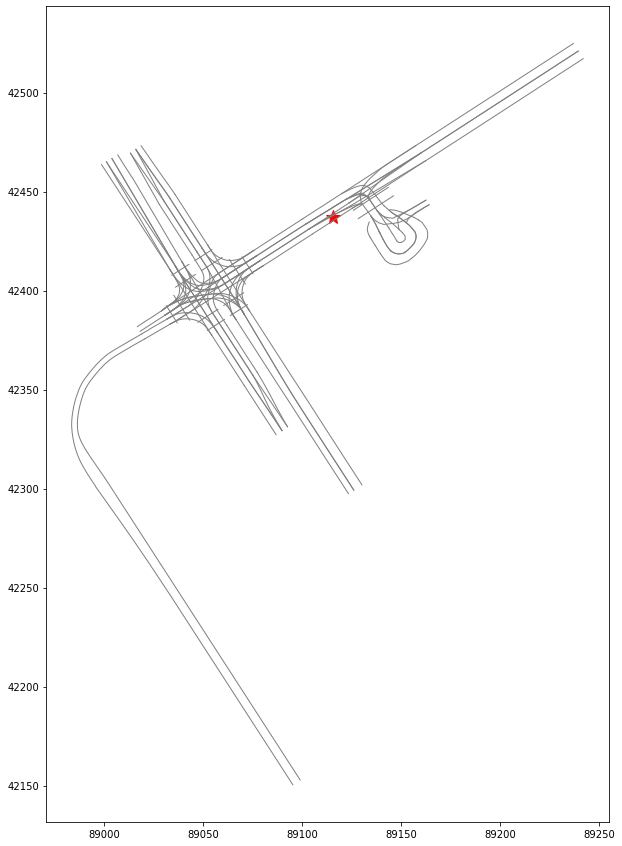

In [14]:
fig, ax = plt.subplots(figsize=(20,15))

history_trajectory_transform
ax.plot(history_trajectory_transform[-1, 0, -1], history_trajectory_transform[-1, 1, -1], 'r*', markersize=15, label='Ego Vehicle')

for lanelet in nearby_lanelets:
    # plot_linestring(lanelet.centerline, ax, "blue", "-", "centerline")
    color = "gray"
    linewidth=1
    plot_linestring(lanelet.leftBound, ax, color, "-", label=f"leftBound_{lanelet.id}", linewidth=linewidth)
    plot_linestring(lanelet.rightBound, ax, color, "-", label=f"rightBound_{lanelet.id}", linewidth=linewidth)

print(history_trajectory_transform[-1, 0, -1], history_trajectory_transform[-1, 1, -1])
ax.set_aspect('equal')
# ax.legend()

In [15]:
history_trajectory_transform[-1, 0:3, -1]

array([8.91154919e+04, 4.24373948e+04, 6.60777441e+00])

#### Visualize routes

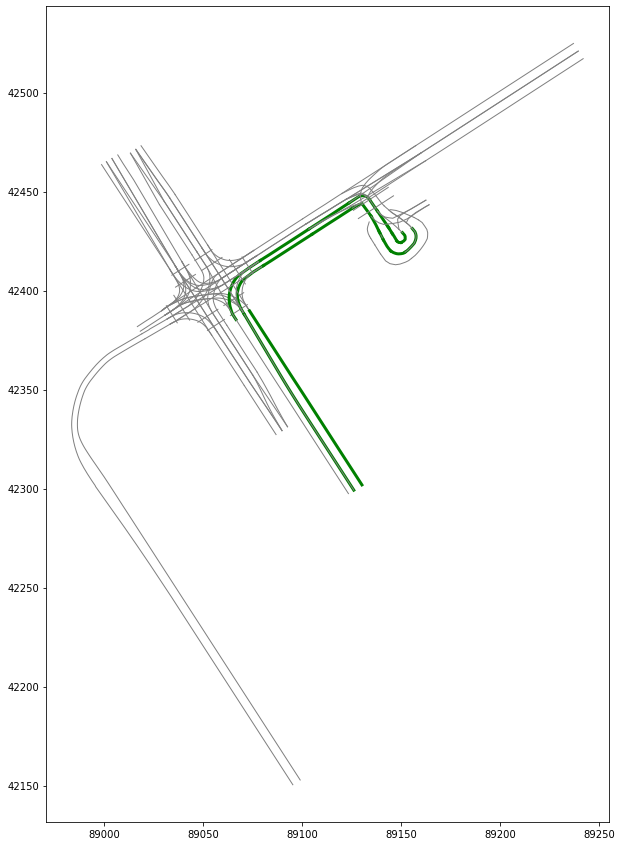

In [16]:
fig, ax = plt.subplots(figsize=(20,15))
for lanelet in nearby_lanelets:
    # plot_linestring(lanelet.centerline, ax, "blue", "-", "centerline")
    if lanelet.id in routes:
        color = "green"
        linewidth=3
    else:
        color = "gray"
        linewidth=1
    plot_linestring(lanelet.leftBound, ax, color, "-", label=f"leftBound_{lanelet.id}", linewidth=linewidth)
    plot_linestring(lanelet.rightBound, ax, color, "-", label=f"rightBound_{lanelet.id}", linewidth=linewidth)

ax.set_aspect('equal')
# ax.legend()

#### Visualize History and Future

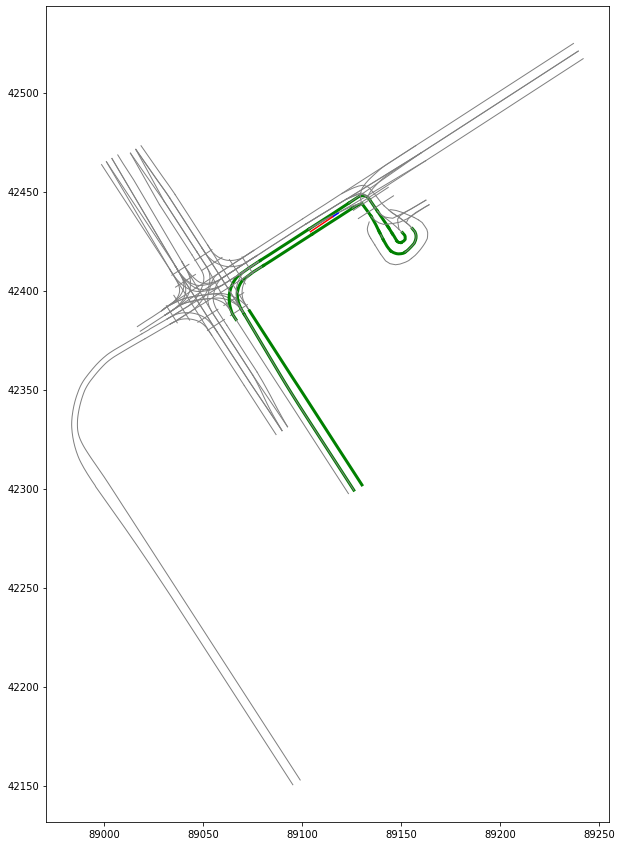

In [17]:
fig, ax = plt.subplots(figsize=(20,15))
for lanelet in nearby_lanelets:
    # plot_linestring(lanelet.centerline, ax, "blue", "-", "centerline")
    if lanelet.id in routes:
        color = "green"
        linewidth=3
    else:
        color = "gray"
        linewidth=1
    plot_linestring(lanelet.leftBound, ax, color, "-", label=f"leftBound_{lanelet.id}", linewidth=linewidth)
    plot_linestring(lanelet.rightBound, ax, color, "-", label=f"rightBound_{lanelet.id}", linewidth=linewidth)


ax.plot(history_trajectory_transform[:, 0, 3], history_trajectory_transform[:, 1, 3], "b-")
ax.plot(future_trajectory_transform[:, 0, 3], future_trajectory_transform[:, 1, 3], "r-")

ax.set_aspect('equal')
# ax.legend()

#### Visualize traffic light

In [18]:
current_traffic_light_status

{'10272': [{'color': 1, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '10277': [{'color': 1, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '179684': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '179706': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '179772': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '179904': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017698': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017773': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017817': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017861': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017905': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017971': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2017993': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],
 '2018037': [{'color': 0, 'shape': 1, 'status': 0, 'confidence': 1.0}],


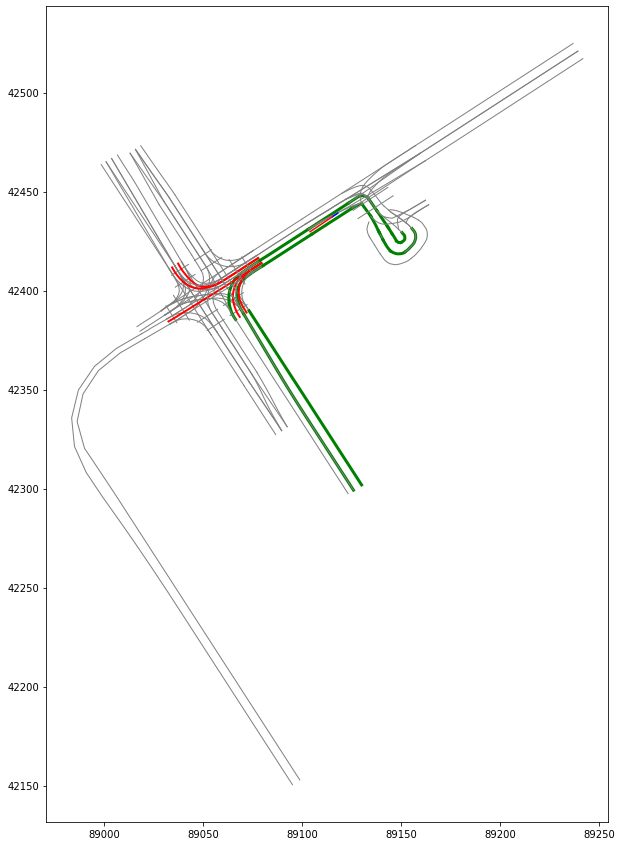

In [19]:
fig, ax = plt.subplots(figsize=(20,15))
for lanelet in nearby_lanelets:
    
    ## Deal with routes
    if lanelet.id in routes:
        color = "green"
        linewidth=3
    else:
        color = "gray"
        linewidth=1

    turn_direction =  LANELET_TURN_DIRECTION_MAPPING[get_turn_direction(lanelet)]
    ## Deal with Traffic Light
    traffic_light_ids_connected_to_lanelet = lanelet.trafficLights()
    if len(traffic_light_ids_connected_to_lanelet) == 0:
        ## This means that this lanelet does not bind to traffic_light
        pass
    else:
        main_traffic_group_id = traffic_light_ids_connected_to_lanelet[0].id
        if str(main_traffic_group_id) in current_traffic_light_status:
            current_traffic_group = current_traffic_light_status[str(main_traffic_group_id)]
            light = identify_current_light_status(turn_direction, current_traffic_group)
            resolution = 1.0
            center_line = utilities.generateFineCenterline(lanelet, resolution)
            if light == 0:
                pass # no detected traffic_lights
            elif light == 1: # RED
                plot_linestring(center_line, ax, "red", "-", linewidth=2)
            elif light == 2: # AMBER
                plot_linestring(center_line, ax, "yellow", "-", linewidth=2)
            elif light == 3: # GREEN
                plot_linestring(center_line, ax, "green", "-", linewidth=2)

    
    plot_linestring(resampled_lanelets[lanelet.id]["left_bound"], ax, color, "-", label=f"leftBound_{lanelet.id}", linewidth=linewidth)
    plot_linestring(resampled_lanelets[lanelet.id]["right_bound"], ax, color, "-", label=f"rightBound_{lanelet.id}", linewidth=linewidth)

## Deal with trajectories
ax.plot(history_trajectory_transform[:, 0, 3], history_trajectory_transform[:, 1, 3], "b-")
ax.plot(future_trajectory_transform[:, 0, 3], future_trajectory_transform[:, 1, 3], "r-")

ax.set_aspect('equal')

### Visualize in Local Coordinate


In E2E learning, we usually need to transform everything into local coordinate. Including all the lanes and objects.

Based on the nature of machine learning training, and to better leverage the lanelet2 APIs, here are the recommended workflow:

1. Preprocessing the maps, resample lanelets beforehands.
2. For each frame
    - Take the lastest history pose as the ego transform.
    - Takes all the lanelets and objects transformed to local coordinates.
    - For objects, there are "global_footprint".
       - If it is of shape [4, 3], then we treat that as an rectangle.
       - Otherwise, it will be an polygon, for simplicity, we fit a rotated bounding box to the polygon.

In [20]:
## Preprocess map
lane_point_number = 20 ## This is a parameter to help fix our number of points to present a certain lanelet -> this will be helpful in some of the learning algorithms.
resampled_lanelets = dict()
for lanelet in map_object.laneletLayer:
    resampled_lanelets[int(lanelet.id)] = dict()
    left_length = lanelet2.geometry.length(lanelet.leftBound)
    right_length = lanelet2.geometry.length(lanelet.rightBound)
    length = max(left_length, right_length)
    if length < 0.001:
        continue
    resolution = length / (lane_point_number - 1) + 0.0001 # make sure the distance/resolution == self.lane_point_number
    right_bound = utilities.getRightBoundWithOffset(lanelet, 0.0, resolution)
    left_bound = utilities.getLeftBoundWithOffset(lanelet, 0.0, resolution)
    center_line = utilities.generateFineCenterline(lanelet, resolution)

    resampled_lanelets[int(lanelet.id)]["right_bound"] = right_bound
    resampled_lanelets[int(lanelet.id)]["left_bound"] = left_bound
    resampled_lanelets[int(lanelet.id)]["center_line"] = center_line

In [21]:
a = np.array(history_trajectory_transform[-1], dtype=np.float64)
b = np.linalg.inv(a)
a, b, a@b

(array([[-8.32313093e-01,  5.54222485e-01,  9.60999836e-03,
          8.91154919e+04],
        [-5.54296289e-01, -8.32072192e-01, -2.02852604e-02,
          4.24373948e+04],
        [-3.24633505e-03, -2.22104743e-02,  9.99748046e-01,
          6.60777441e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]),
 array([[-8.32313093e-01, -5.54296289e-01, -3.24633505e-03,
          9.76949026e+04],
        [ 5.54222485e-01, -8.32072192e-01, -2.22104743e-02,
         -1.40786864e+04],
        [ 9.60999836e-03, -2.02852604e-02,  9.99748046e-01,
         -2.15223316e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]),
 array([[ 1.00000000e+00, -1.42030485e-17,  0.00000000e+00,
          0.00000000e+00],
        [ 4.13081028e-17,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [-1.73472348e-18, -3.46944695e-18,  1.00000000e+00,
         -2.66453526e-14],
        [ 0.00000000e+00,  0.00000000e+

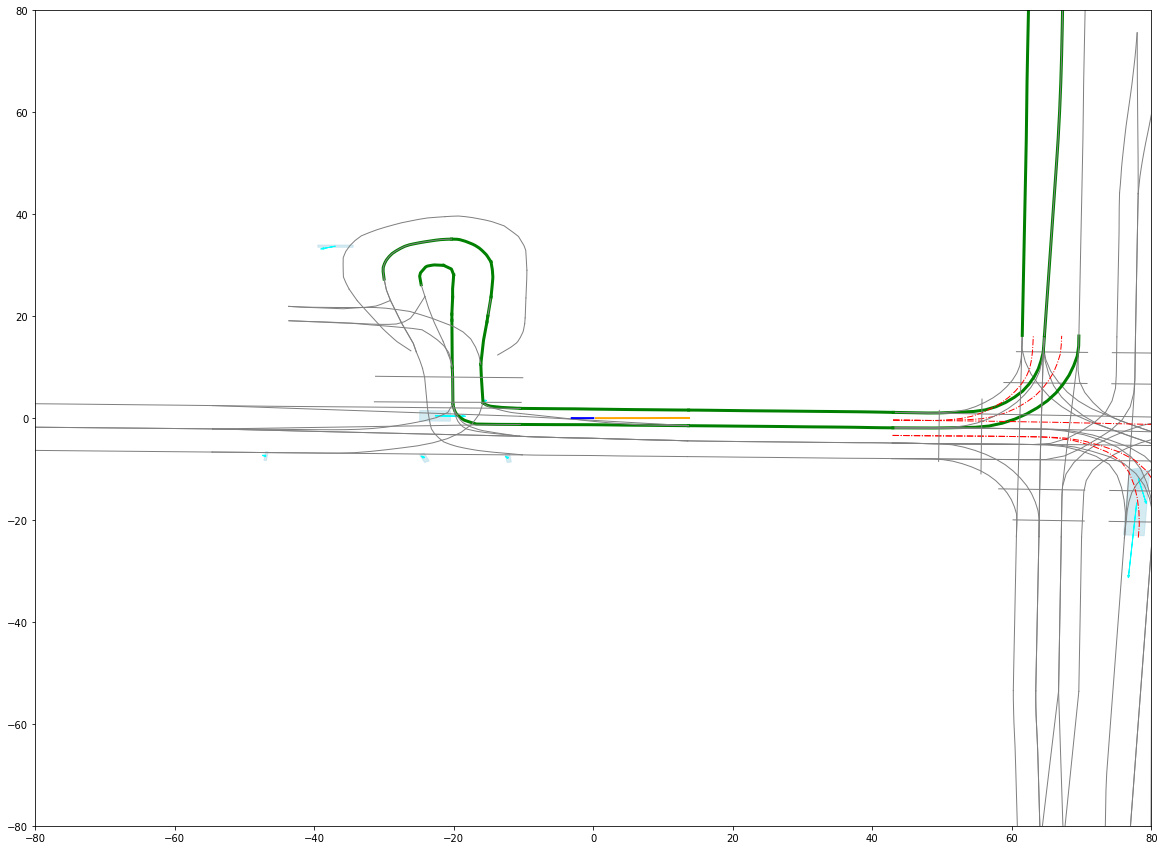

In [22]:
from matplotlib.patches import Polygon


def draw_frame(frame, ax):
    object_transforms = np.array([obj["transform"] for obj in frame["objects"]]) #[N_o, 4, 4] map frame
    object_velocities = np.array([obj["velocity"] for obj in frame["objects"]]) #[N_o, 3] map frame
    
    processed_footprints = []
    for obj in frame["objects"]:
        footprint = obj["global_footprint"]
        if len(footprint) != 4:
            bbox = fit_rotated_bbox(np.array(footprint)) # I made this for torch tensor..
            processed_footprints.append(bbox.numpy())
        else:
            processed_footprints.append(np.array(footprint))
    object_footprints = np.stack(processed_footprints, axis=0) # [8, 4, 3]
    
    # Extract data from frame
    history_trajectory_transform = np.array(frame["history_trajectories_transform_list"], dtype=np.float32)  # [N_h, 4, 4] map frame
    future_trajectory_transform = np.array(frame["future_trajectories_transform_list"], dtype=np.float32)    # [N_f, 4, 4] 
    history_trajectory_speed = np.array(frame["history_trajectories_speed_list"], dtype=np.float32)          # [N_h, 1]
    future_trajectory_speed = np.array(frame["future_trajectories_speed_list"], dtype=np.float32)            # [N_f, 1]
    nearby_lanelets_ids = frame["nearby_lanelets_ids"] # list of ids
    routes = frame["routes"] # list of ids
    current_traffic_light_status = frame["current_traffic_light_status"]  # dictionary of list of group id
    #nearby_lanelets = [map_object.laneletLayer.get(idx) for idx in nearby_lanelets_ids]
    nearby_lanelets = [map_object.laneletLayer.get(idx) for idx in nearby_lanelets_ids]
    
    # Extract geometric information (map frame) from pre-compute data
    left_boundaries = np.array([[(p.x, p.y, p.z) for p in resampled_lanelets[int(idx)]["left_bound"]] for idx in nearby_lanelets_ids]) # [N_lanelet, lane_point_number=20, 2]
    right_boundaries = np.array([[(p.x, p.y, p.z) for p in resampled_lanelets[int(idx)]["right_bound"]] for idx in nearby_lanelets_ids]) # [N_lanelet, lane_point_number=20, 2]
    center_boundaries = np.array([[(p.x, p.y, p.z) for p in resampled_lanelets[int(idx)]["center_line"]] for idx in nearby_lanelets_ids]) # [N_lanelet, lane_point_number=20, 2]
    
    ego_transform = history_trajectory_transform[-1] # [4, 4]
    ego_transform_inv = np.linalg.inv(ego_transform) # [4, 4]
    
    # Transform map-frame transform into local
    future_trajectory_transform = np.matmul(ego_transform_inv, future_trajectory_transform)
    history_trajectory_transform = np.matmul(ego_transform_inv, history_trajectory_transform)
    object_transforms = np.matmul(ego_transform_inv, object_transforms)
    
    rotation_matrix = ego_transform_inv[:3, :3]  # [3, 3]
    object_velocities = np.matmul(rotation_matrix, object_velocities[..., None])[...,  0]  # [N_o, 3]

    ## Utilize R^(-1)  @  ([x,y,z] - [xo,yo,zo])
    # Transform footprints from global to ego frame
    # First convert 2D points to homogeneous coordinates
    footprints_homogeneous = np.ones([object_footprints.shape[0], 
                                    object_footprints.shape[1], 
                                    4])  # [N_o, 4, 4]
    footprints_homogeneous[..., :3] = object_footprints  # Set x,y coordinates
    footprints_homogeneous = footprints_homogeneous.transpose([0, 2, 1])  # Trans
    footprints_homogeneous = np.matmul(
        ego_transform_inv, footprints_homogeneous
    )  # [N_o, 4, 4]
    footprints_homogeneous = footprints_homogeneous.transpose([0, 2, 1])  # Trans
    object_footprints = footprints_homogeneous[..., :2]  # [N_o, 4, 2]
    # print(data["objects_footprint"][data["objects_mask"]], ego_transform)
    
    # Transform map elements
    # Transform left boundaries
    left_boundaries_homogeneous = np.ones([left_boundaries.shape[0],
                                        left_boundaries.shape[1],
                                        4])
    left_boundaries_homogeneous[..., :3] = left_boundaries
    left_boundaries_homogeneous = left_boundaries_homogeneous.transpose([0, 2, 1]) 
    left_boundaries_homogeneous = np.matmul(ego_transform_inv, left_boundaries_homogeneous)
    left_boundaries = left_boundaries_homogeneous[:, :2, :].transpose([0, 2, 1])  # [N_lanelet, lane_point_number=20, 2]
    # Transform right boundaries
    right_boundaries_homogeneous = np.ones([right_boundaries.shape[0],
                                            right_boundaries.shape[1],
                                            4])
    right_boundaries_homogeneous[..., :3] = right_boundaries
    right_boundaries_homogeneous = right_boundaries_homogeneous.transpose([0, 2, 1]) 
    right_boundaries_homogeneous = np.matmul(ego_transform_inv, right_boundaries_homogeneous)
    right_boundaries = right_boundaries_homogeneous[:, :2, :].transpose([0, 2, 1]) # [N_lanelet, lane_point_number=20, 2]
    
    # Transform centerline
    centerline_homogeneous = np.ones([center_boundaries.shape[0],
                                            center_boundaries.shape[1],
                                            4])
    centerline_homogeneous[..., :3] = center_boundaries
    centerline_homogeneous = centerline_homogeneous.transpose([0, 2, 1]) 
    centerline_homogeneous = np.matmul(ego_transform_inv, centerline_homogeneous)
    center_boundaries = centerline_homogeneous[:, :2, :].transpose([0, 2, 1]) # [N_lanelet, lane_point_number=20, 2]
    
    
    # plot objects
    for i in range(len(frame["objects"])):
        footprint = object_footprints[i]  # [4, 2]
        velocity = object_velocities[i]     # [3]
        
        # Plot footprint
        polygon = Polygon(footprint, fill=True, alpha=0.5, color='lightblue')
        ax.add_patch(polygon)
        
        # Plot velocity vector
        center = np.mean(footprint, axis=0)
        ax.arrow(center[0].item(), center[1].item(), 
                velocity[0].item(), velocity[1].item(),
                head_width=0.3, head_length=0.5, fc='cyan', ec='cyan')
    
    # Plot lanelets
    for i, lanelet in enumerate(nearby_lanelets):
        # Determine lanelet color and width based on whether it's in routes
        color = "green" if lanelet.id in routes else "gray"
        linewidth = 3 if lanelet.id in routes else 1
    
        turn_direction = LANELET_TURN_DIRECTION_MAPPING[get_turn_direction(lanelet)]
        
        # Handle traffic lights
        traffic_light_ids = lanelet.trafficLights()
        if traffic_light_ids:
            main_traffic_group_id = traffic_light_ids[0].id
            if str(main_traffic_group_id) in current_traffic_light_status:
                current_traffic_group = current_traffic_light_status[str(main_traffic_group_id)]
                light = identify_current_light_status(turn_direction, current_traffic_group)
                
                if light > 0:  # If there's a valid traffic light status
                    resolution = 1.0
                    light_colors = {1: "red", 2: "yellow", 3: "green"}
                    if light in light_colors:
                        ax.plot(center_boundaries[i, :, 0], center_boundaries[i, :, 1], "-.", color=light_colors[light], linewidth=1)
    
        # Plot lanelet boundaries
        ax.plot(left_boundaries[i, :, 0], left_boundaries[i, :, 1], "-", color=color, linewidth=linewidth)
        ax.plot(right_boundaries[i, :, 0], right_boundaries[i, :, 1], "-", color=color, linewidth=linewidth)
    
    # Plot trajectories
    ax.plot(history_trajectory_transform[:, 0, 3], history_trajectory_transform[:, 1, 3], 
            "-",color="blue", label="History Trajectory", linewidth=2)
    ax.plot(future_trajectory_transform[:, 0, 3], future_trajectory_transform[:, 1, 3], 
            "-",color="orange", label="Future Trajectory", linewidth=2)
    
    ax.set_xlim(-80, 80)
    ax.set_ylim(-80, 80)

fig, ax = plt.subplots(figsize=(20, 15))
draw_frame(frame, ax)

In [23]:
from IPython.display import display, HTML
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
def create_final_video_animation(cache_data, key_frame_ids, filename='animation.gif'):
    """Save animation as GIF file"""
    fig, ax = plt.subplots(figsize=(20, 15))
    
    def update(frame_idx):
        fig.clear()
        ax = fig.add_subplot(111)
        frame_id = key_frame_ids[frame_idx]
        frame = cache_data[str(frame_id)]
        draw_frame(frame, ax)
        return ax,
    
    anim = FuncAnimation(
        fig, 
        update,
        frames=len(key_frame_ids),
        interval=200,
        blit=False
    )
    
    # Use PillowWriter instead of FFMpegWriter
    writer = animation.PillowWriter(fps=8, bitrate=1800,)  # Lower fps for GIF to reduce file size
    anim.save(filename, writer=writer)
    plt.close()
    
    return HTML(f"""
    <img src="{filename}">
    """)


In [24]:
# this will take some time
results = create_final_video_animation(cache_data, key_frame_ids[0:1000], filename='tutorial_docs/final_animation.gif')
display(results)